# Prediction overlap: dynamic FER

Section 5.3.1 complementarity analysis for the Image and FEA sequence baselines on EmoHeVRDB.
Run all cells in order. Requirements: Python 3, pandas, NumPy, Matplotlib, Seaborn, and Jupyter.
No model inference or raw dataset access is needed.

## Input and outputs

The input is `emohevrdb-dfer/5_dynamic_facial_expression_recognition/dynamic_test_predictions.csv`,
created by `collect_dynamic_test_predictions.ipynb` in the same Section 5 directory.
The notebook exports `prediction_cases_data.csv` there and `dfer_prediction_overlap.pdf` and `.png` under `figures/`.

## Definitions and counting unit

Columns represent **ground-truth emotion classes**. Rows represent **both correct**, **only FEA correct**,
**only image correct**, and **both wrong**. Both wrong does not require the same wrong label.
Central and Side views are pooled: **108 comparisons per class, 756 in total, from 378 reenactments**.
Each reenactment's single FEA prediction is paired with its two image-view predictions.
These are descriptive view-level counts, not 756 independent reenactments.
Percentages are normalized within each class.


In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

print(f"pandas {pd.__version__}; NumPy {np.__version__}; Matplotlib {matplotlib.__version__}; Seaborn {sns.__version__}")


pandas 2.2.3; NumPy 1.26.4; Matplotlib 3.9.4; Seaborn 0.13.2


In [2]:
PREDICTIONS_PATH = Path("../../dynamic_test_predictions.csv")
ANALYSIS_DIR = Path(".")

predictions = pd.read_csv(PREDICTIONS_PATH)

## Compute overlap from saved test predictions

Validate pairing and class labels, then count all four correctness groups by emotion and view. Zero-count groups are retained in the exported CSV.

In [3]:
CLASSES = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
ROW_NAMES = ["Both correct", "Only FEA correct", "Only image correct", "Both wrong"]
CASES = ["both_correct", "image_wrong_fea_correct", "image_correct_fea_wrong", "both_wrong"]
required = ["sample_id", "reenactment_id", "camera_index", "perspective", "true_label_id",
            "true_label", "image_pred_id", "fea_pred_id"]
missing = set(required) - set(predictions.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")
assert predictions[required].notna().all().all(), "Missing prediction identifiers or labels."
assert len(predictions) == 756 and predictions["sample_id"].is_unique
assert predictions["reenactment_id"].nunique() == 378
assert set(predictions["perspective"]) == {"Central", "Side"}
assert set(predictions["camera_index"]) == {0, 1}
assert predictions["perspective"].eq(predictions["camera_index"].map({0: "Central", 1: "Side"})).all()
for column in ["true_label_id", "image_pred_id", "fea_pred_id"]:
    assert predictions[column].isin(range(7)).all(), f"Invalid class IDs in {column}."
assert predictions["true_label"].eq(predictions["true_label_id"].map(dict(enumerate(CLASSES)))).all()
reenactments = predictions.groupby("reenactment_id")
assert reenactments.size().eq(2).all()
assert reenactments["camera_index"].nunique().eq(2).all()
assert reenactments["true_label_id"].nunique().eq(1).all()
assert reenactments["fea_pred_id"].nunique().eq(1).all()

image_correct = predictions["image_pred_id"].eq(predictions["true_label_id"])
fea_correct = predictions["fea_pred_id"].eq(predictions["true_label_id"])
predictions["Case"] = np.select(
    [image_correct & fea_correct, ~image_correct & fea_correct, image_correct & ~fea_correct],
    CASES[:3], default="both_wrong"
)
index = pd.MultiIndex.from_product(
    [CLASSES, ["Central", "Side"], CASES], names=["Emotion", "Perspective", "Case"]
)
prediction_cases = (
    predictions.rename(columns={"true_label": "Emotion", "perspective": "Perspective"})
    .groupby(["Emotion", "Perspective", "Case"]).size()
    .reindex(index, fill_value=0).rename("Count").reset_index()
)
assert prediction_cases.groupby(["Emotion", "Perspective"])["Count"].sum().eq(54).all()
counts_table = (
    prediction_cases.groupby(["Case", "Emotion"])["Count"].sum()
    .unstack("Emotion").reindex(index=CASES, columns=CLASSES)
)
DFER_COUNTS = counts_table.to_numpy(dtype=int)
np.testing.assert_array_equal(DFER_COUNTS.sum(axis=0), np.full(7, 108))
assert DFER_COUNTS.sum() == 756
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
COUNTS_PATH = ANALYSIS_DIR / "prediction_cases_data.csv"
prediction_cases.to_csv(COUNTS_PATH, index=False)
print(f"Exported {len(prediction_cases)} class/view/outcome rows to {COUNTS_PATH}")
display(counts_table.rename(index=dict(zip(CASES, ROW_NAMES))))
print("Row totals:", DFER_COUNTS.sum(axis=1).tolist())
unique_fea = predictions.drop_duplicates("reenactment_id")
fea_correct_unique = unique_fea["fea_pred_id"].eq(unique_fea["true_label_id"]).sum()
oracle_correct = (image_correct | fea_correct).sum()
print(f"Image: {image_correct.sum()}/756 = {image_correct.mean():.2%}")
print(f"FEA: {fea_correct_unique}/378 = {fea_correct_unique / 378:.2%}")
print(f"Prediction-selection oracle: {oracle_correct}/756 = {oracle_correct / 756:.2%}")


Exported 56 class/view/outcome rows to prediction_cases_data.csv


Emotion,Anger,Disgust,Fear,Happiness,Neutral,Sadness,Surprise
Case,,,,,,,
Both correct,40,51,47,99,75,79,85
Only FEA correct,16,9,19,9,27,17,19
Only image correct,10,23,24,0,6,9,2
Both wrong,42,25,18,0,0,3,2


Row totals: [476, 116, 74, 90]
Image: 550/756 = 72.75%
FEA: 296/378 = 78.31%
Prediction-selection oracle: 666/756 = 88.10%


## Figure settings

The existing blue heatmap design is preserved, including its default 0–92% color range and text colors. Set `color_max=100` for a 0–100% scale or `None` for automatic scaling. Font sizes and export settings are configurable below.

In [4]:
STYLE = dict(
    figsize=(13, 6),  # Figure width and height in inches.
    outcomes=["Both\ncorrect", "Only\nFEA\ncorrect", "Only\nimage\ncorrect", "Both\nwrong"],  # Row labels; \n inserts line breaks.
    tick_size=20,  # Font size of row and column labels in points.
    tick_weight="bold",  # Font weight of row and column labels.
    count_size=30,  # Font size of cell counts in points.
    percent_size=20,  # Font size of cell percentages in points.
    percent_decimals=2,  # Number of decimal places shown for percentages.
    count_y=0.4,  # Vertical count position within each cell: 0 = top, 1 = bottom.
    percent_y=0.72,  # Vertical percentage position within each cell: 0 = top, 1 = bottom.
    color_max=92,  # Color-scale maximum in percent; None uses each plot's maximum, 100 fixes the scale.
    end_color="#04092e",  # Color at the upper end of the blue color scale.
    square=False,  # If True, enforce square heatmap cells.
    linewidths=2,  # Width of the white lines separating cells in points.
    tick_length=6,  # Length of axis tick marks in points.
    tick_width=2,  # Width of axis tick marks in points.
    tick_pad=6,  # Distance between tick marks and their labels in points.
    label_linespacing=1.15,  # Line-spacing factor for multiline row labels.
    layout_pad=0.6,  # Padding around the figure as a fraction of the default font size.
    font_family="DejaVu Sans",  # Font family used throughout the figure.
    title=None,  # Optional figure title; None omits the title.
)

EXPORT_DIR = ANALYSIS_DIR / "figures" # Independent of the working directory.
EXPORT_FORMATS = ("pdf", "png")  # File formats to export; optionally add "svg".
EXPORT_DPI = 400  # Resolution in dots per inch for PNG and rasterized elements.
EXPORT_PAD_INCHES = 0.02  # Extra margin around the tightly cropped export, in inches.
SAVE_FIGURES = True  # If True, save the figures; if False, only display them.

In [5]:
def plot_prediction_overlap(counts, style):
    """Plot the four correctness groups; percentages are normalized by class."""
    counts = np.asarray(counts)
    if counts.shape != (4, len(CLASSES)) or not np.isfinite(counts).all():
        raise ValueError("Expected a finite 4 × 7 count matrix.")
    if np.any(counts < 0) or np.any(counts != np.floor(counts)) or np.any(counts.sum(axis=0) == 0):
        raise ValueError("Counts must be nonnegative integers with positive column totals.")
    percentages = 100 * counts / counts.sum(axis=0)
    vmax = percentages.max() if style["color_max"] is None else style["color_max"]
    if vmax <= 0 or vmax < percentages.max():
        raise ValueError("color_max must cover every cell percentage.")
    blues = plt.get_cmap("Blues")
    stops = [(x * 0.88, blues(x)) for x in np.linspace(0, 1, 12)]
    cmap = LinearSegmentedColormap.from_list("extended_blues", stops + [(1, style["end_color"])])
    norm = Normalize(0, vmax)
    with plt.rc_context({"font.family": style["font_family"], "pdf.fonttype": 42,
                         "ps.fonttype": 42, "svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=style["figsize"])
        sns.heatmap(percentages, ax=ax, cmap=cmap, norm=norm, cbar=False,
                    square=style["square"], xticklabels=CLASSES,
                    yticklabels=style["outcomes"], linewidths=style["linewidths"], linecolor="white")
        for (row, col), count in np.ndenumerate(counts):
            # rgb = np.array(cmap(norm(percentages[row, col]))[:3])
            # linear = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
            # color = "#ffffff" if linear @ [0.2126, 0.7152, 0.0722] < 0.179 else "#000000"
            color = "white" if percentages[row, col] > 50 else "black"
            ax.text(col + 0.5, row + style["count_y"], str(int(count)),
                    ha="center", va="center", fontsize=style["count_size"], fontweight="bold", color=color)
            ax.text(col + 0.5, row + style["percent_y"],
                    f"{percentages[row, col]:.{style['percent_decimals']}f}%",
                    ha="center", va="center", fontsize=style["percent_size"], color=color)
        ax.set_xticklabels(CLASSES, rotation=0, fontsize=style["tick_size"], fontweight=style["tick_weight"])
        ax.set_yticklabels(style["outcomes"], rotation=0, fontsize=style["tick_size"],
                           fontweight=style["tick_weight"], va="center", linespacing=style["label_linespacing"])
        ax.tick_params(axis="both", length=style["tick_length"], width=style["tick_width"], pad=style["tick_pad"])
        if style["title"]:
            ax.set_title(style["title"], fontsize=style["tick_size"], pad=12)
        fig.tight_layout(pad=style["layout_pad"])
    return fig, ax


def export_figure(fig, stem):
    """Export to the configured directory; reruns replace files with the same name."""
    if not SAVE_FIGURES:
        return
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"}):
        for extension in EXPORT_FORMATS:
            path = EXPORT_DIR / f"{stem}.{extension}"
            fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", pad_inches=EXPORT_PAD_INCHES)
            print(path)


## DFER overlap

The plotted matrix is computed from the CSV above. Prediction-selection coverage describes how often at least one unimodal prediction is correct; it is not a strict ceiling on learned fusion.

figures/dfer_prediction_overlap.pdf
figures/dfer_prediction_overlap.png


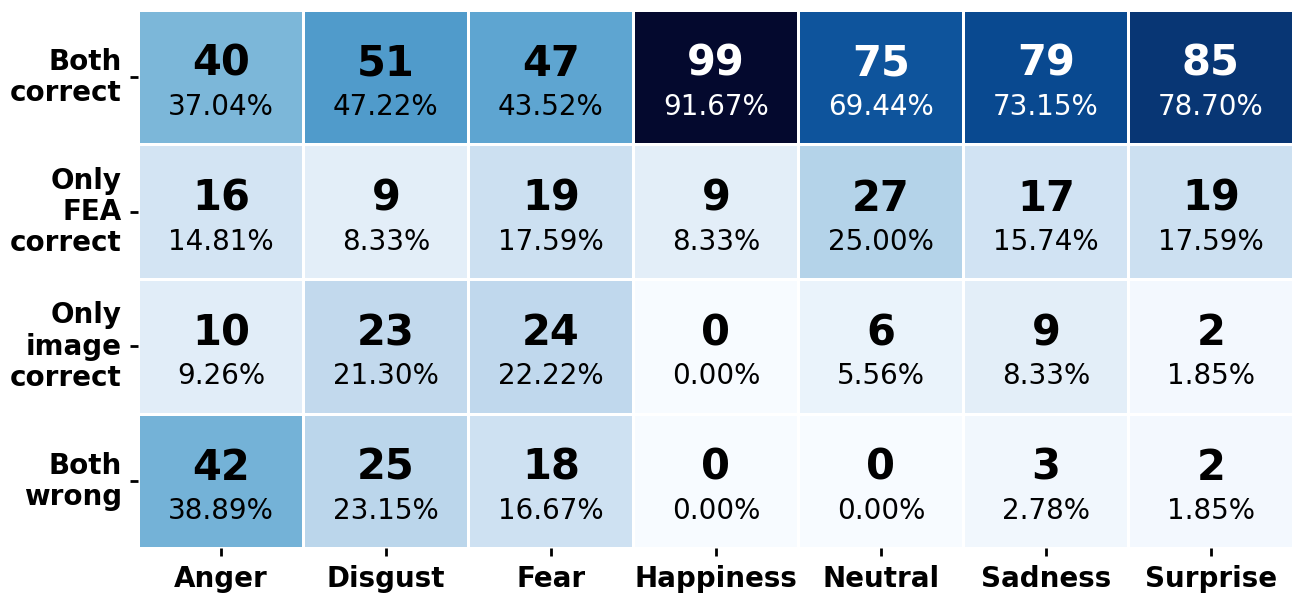

In [6]:
dfer_style = dict(STYLE)  # Example: dict(STYLE, count_size=28)
fig_dfer, ax_dfer = plot_prediction_overlap(DFER_COUNTS, dfer_style)
export_figure(fig_dfer, "dfer_prediction_overlap")
plt.show()
plt.close(fig_dfer)